# InferLite on free Google Colab GPUs (T4)

Measured timings only. Missing methods are labeled **unsupported**, never scored.

**Research question:** can we find a strong TinyLlama config on this T4 without exhaustive search?

**If Colab says the session crashed / disk is full:** Runtime → Disconnect and delete runtime. Then reconnect with a T4 GPU. Do **not** `pip install -r requirements.txt` here — that reinstalls Torch and ONNX and is what fills the disk.

**Setup**

1. Runtime → Change runtime type → **T4 GPU**.
2. Runtime → Disconnect and delete runtime if this is an old session, then reconnect.
3. Run cells in order. Cell 1 clones `https://github.com/Shivani767/llm-inferlite` and fast-forwards to `origin/main` (needed for the search/optimizer code).
4. Cell 2 installs **only** `requirements-colab.txt`. Then: lite quantization suite → figures → **T4 search vs baselines** → skip GGUF unless llama.cpp is installed.

**Published T4 lite (2026-08-25):** FP16 35.0 tok/s vs INT4 15.3 tok/s. Do not cite the old `gptq` bar as GPTQ.
**Published Mac search:** `docs/results/optimizer_macbook/` (GPT-2 / MPS). Do not mix with T4 numbers. After you run the search cells below, paste/save outputs into `docs/results/optimizer_colab_t4/`.


In [5]:
import os, sys, pathlib, subprocess

def is_repo(path):
    return (pathlib.Path(path) / "backend" / "research").is_dir()

REPO_ROOT = None
for cand in [
    pathlib.Path("/content/llm-inferlite"),
    pathlib.Path("/content/llm-inferlite-main"),
    pathlib.Path.cwd(),
    pathlib.Path.cwd().parent,
    pathlib.Path("/content"),
]:
    if is_repo(cand):
        REPO_ROOT = cand
        break
    for name in ("llm-inferlite", "llm-inferlite-main"):
        nested = cand / name
        if is_repo(nested):
            REPO_ROOT = nested
            break
    if REPO_ROOT is not None:
        break

if REPO_ROOT is None:
    dest = pathlib.Path("/content/llm-inferlite")
    print("Repo not found. Cloning https://github.com/Shivani767/llm-inferlite ...")
    subprocess.check_call([
        "git", "clone", "--depth", "1",
        "https://github.com/Shivani767/llm-inferlite.git",
        str(dest),
    ])
    REPO_ROOT = dest
elif (REPO_ROOT / ".git").is_dir():
    # Old clones still have the disk-filling pip cell files; fast-forward to origin/main.
    subprocess.call(["git", "-C", str(REPO_ROOT), "fetch", "--depth", "1", "origin", "main"])
    subprocess.call(["git", "-C", str(REPO_ROOT), "reset", "--hard", "origin/main"])

BACKEND = REPO_ROOT / "backend"
assert (BACKEND / "research").exists(), (
    f"Could not find InferLite backend under {REPO_ROOT}. "
    "Run: !git clone --depth 1 https://github.com/Shivani767/llm-inferlite.git /content/llm-inferlite"
)
os.chdir(BACKEND)
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))
print("REPO_ROOT", REPO_ROOT)
print("BACKEND ", BACKEND)

REPO_ROOT /content/llm-inferlite
BACKEND  /content/llm-inferlite/backend


In [6]:
import shutil
from pathlib import Path

# Free leftover clones / pip cache from a crashed session. Do not reinstall torch.
for extra in (Path("/content/llm-inferlite-main"),):
    if extra.exists() and extra.resolve() != Path(REPO_ROOT).resolve():
        shutil.rmtree(extra, ignore_errors=True)

!pip cache purge -q || true
!df -h / | tail -1
!free -h | head -2

# Slim install only. NEVER: pip install -r requirements.txt on Colab.
!pip install -q -r requirements-colab.txt
print("install done")

overlay         113G   50G   64G  44% /
               total        used        free      shared  buff/cache   available
Mem:            12Gi       978Mi        10Gi       2.0Mi       1.3Gi        11Gi
install done


In [7]:
from research.capabilities import probe
from research.env import collect_environment
import json

env = collect_environment(seed=42)
caps = probe()
print("device:", caps["device"], "cuda:", caps["cuda"], "colab:", env.get("colab"))
print("gpu:", (env.get("torch") or {}).get("gpu"))
print("\nCapability matrix:")
for name, item in caps["experiments"].items():
    print(f"  [{'YES' if item['supported'] else 'NO ':3}] {name}: {item['reason']}")

device: cuda cuda: True colab: True
gpu: {'index': 0, 'name': 'Tesla T4', 'total_memory_mb': 14912.69, 'multi_processor_count': 40, 'major': 7, 'minor': 5}

Capability matrix:
  [YES] transformers_fp32: ready
  [YES] transformers_fp16: fp16 is measured on CUDA or MPS; CPU stays fp32
  [YES] transformers_bf16: bf16 measured on CUDA when the GPU supports it
  [YES] dynamic_int8: PyTorch dynamic int8 on Linear layers (CPU path is the supported one)
  [YES] int8_bnb: ready
  [YES] int4_bnb: ready
  [YES] gptq: ready to attempt GPTQ load
  [NO ] awq: autoawq not available: No module named 'autoawq'
  [NO ] gguf: llama_cpp not available: No module named 'llama_cpp'
  [NO ] vllm: vllm not available: No module named 'vllm'
  [NO ] tensorrt_llm: TensorRT-LLM is not installed or supported on MacBook / free Colab
  [NO ] smoothquant: SmoothQuant is not wired: needs a dedicated calibration toolkit not bundled here
  [NO ] squeezellm: SqueezeLLM is not bundled; no silent fallback numbers are produc

## T4 lite suite

TinyLlama 1.1B. First pass times **fp16, INT8, INT4** when bitsandbytes works. AWQ/GPTQ/GGUF stay **unsupported** unless those libraries and files are present — they are not downloaded just to fill the disk.

After this succeeds you can run `configs/colab_t4.yaml` for KV / speculative / batching.

In [8]:
from research.runner import load_config, run_config

cfg_path = REPO_ROOT / "configs" / "colab_t4_lite.yaml"
cfg = load_config(cfg_path)
cfg["results_dir"] = str(BACKEND / "results" / "colab_t4_lite")

summary = run_config(cfg, results_dir=cfg["results_dir"], make_plots=True)
print("measured", summary["n_measured"], "unsupported", summary["n_unsupported"], "error", summary["n_error"])
print("bundle", summary["bundle"])
print("csv", summary["csv"])
print("plots", summary["plots"])
print("pareto", json.dumps(summary["pareto"], indent=2, default=str)[:2000])

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


[transformers] torch_dtype is deprecated; bitsandbytes logged repeated MatMul8bitLt bfloat16→float16 casts (truncated).


measured 4 unsupported 4 error 0
bundle /content/llm-inferlite/backend/results/colab_t4_lite/colab_t4_lite.json
csv /content/llm-inferlite/backend/results/colab_t4_lite/experiments.csv
plots ['/content/llm-inferlite/backend/results/colab_t4_lite/figures/quantization_comparison.png', '/content/llm-inferlite/backend/results/colab_t4_lite/figures/pareto_throughput_memory.png', '/content/llm-inferlite/backend/results/colab_t4_lite/figures/unsupported_experiments.png']
pareto [
  {
    "experiment_id": "2026-08-25T171238Z_fp16_2840abf2",
    "method": "fp16",
    "backend": "transformers",
    "model_id": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "device": "cuda",
    "objectives": {
      "p95_latency_ms": 467.91840940009024,
      "memory_mb": 2107.525,
      "tokens_per_sec": 34.97482779291871
    }
  },
  {
    "experiment_id": "2026-08-25T171320Z_int4_bnb_eaa6c99f",
    "method": "int4_bnb",
    "backend": "transformers",
    "model_id": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "devic

pareto_throughput_memory.png


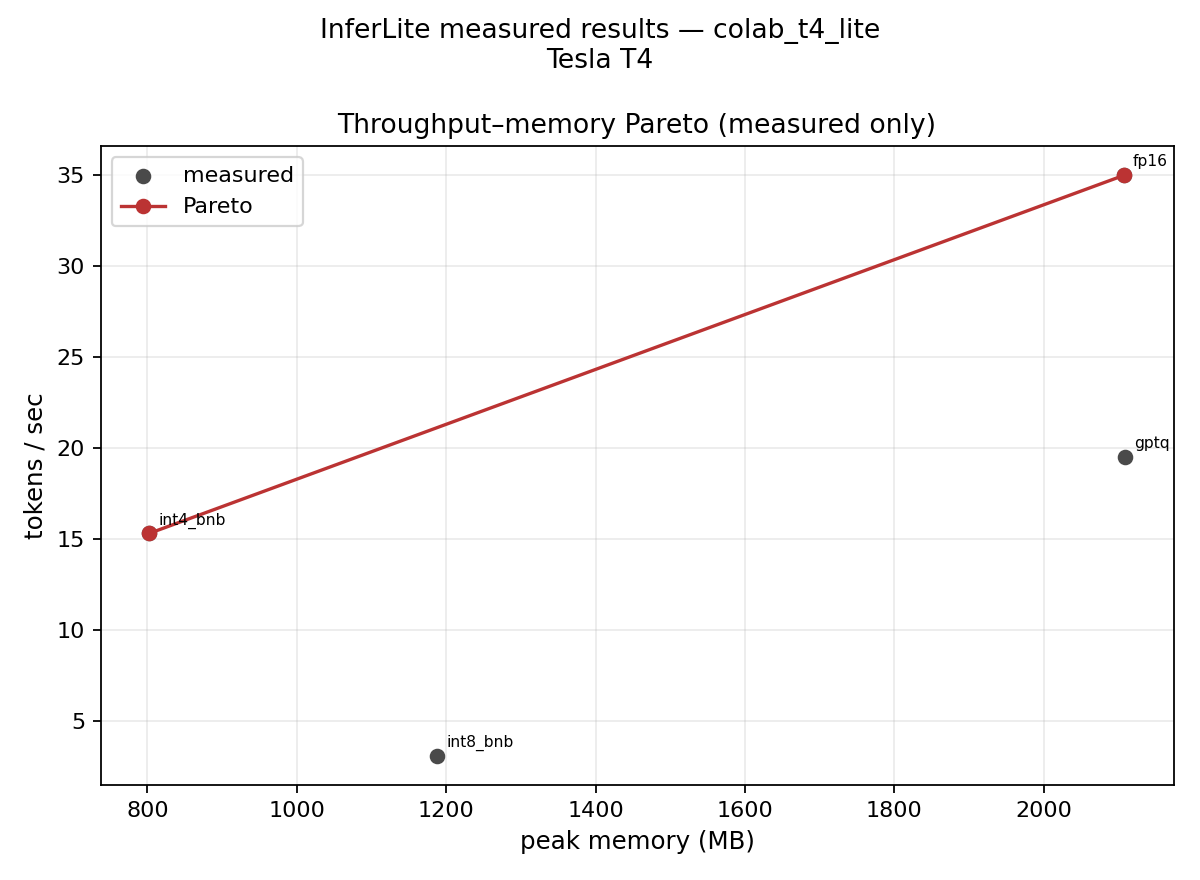

quantization_comparison.png


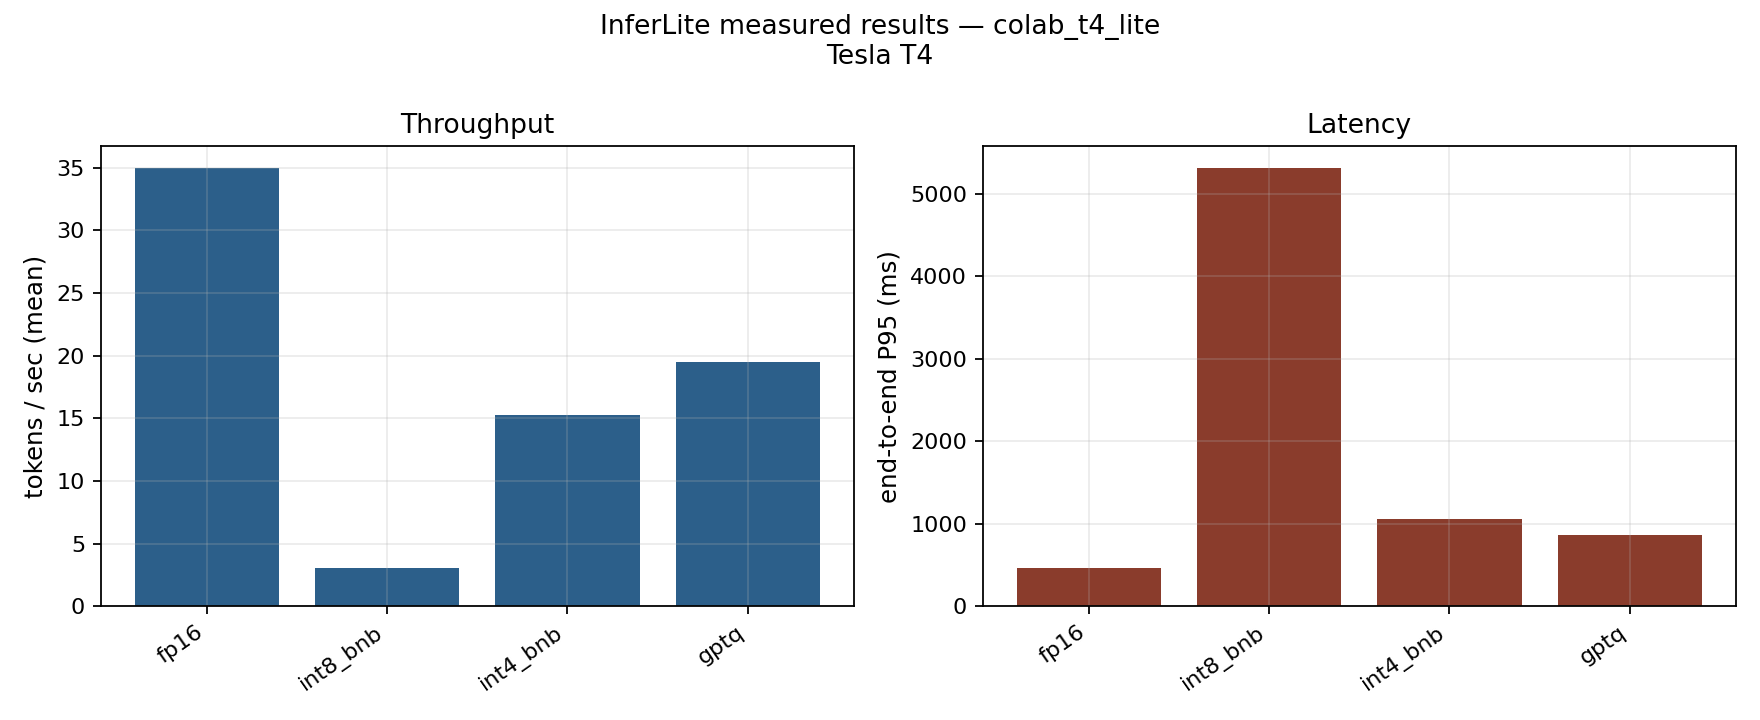

unsupported_experiments.png


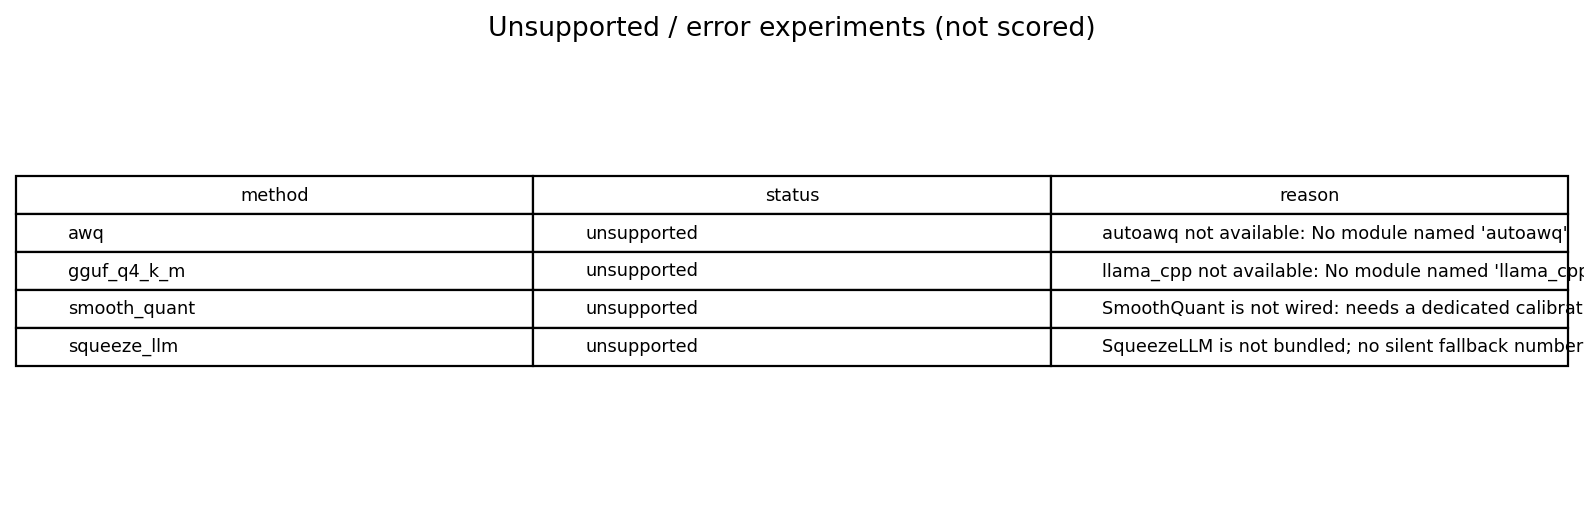

In [9]:
from IPython.display import Image, display
from pathlib import Path

fig_dir = Path(cfg["results_dir"]) / "figures"
if fig_dir.exists():
    for p in sorted(fig_dir.glob("*.png")):
        print(p.name)
        display(Image(filename=str(p)))
else:
    print("No figures yet. Check n_measured in the previous cell.")

## T4 search vs baselines

Same research question as the Mac study, **new measurements on this T4**. Grid is 4 jobs: `fp16` / `int4_bnb` × context 32 / 64 × 8 new tokens. InferLite and random get budget 3. INT8 is omitted (it was ~10× slower than FP16 on the lite suite). GPTQ is omitted (no checkpoint).

This is wall-clock, not the queueing simulator. After it finishes, download `backend/results/optimizer_colab_t4/` or copy the printed comparison table into the GitHub issue/chat so it can be published.


In [ ]:
from research.runner import load_config, run_config
from IPython.display import Image, display
from pathlib import Path
import json

cfg_path = REPO_ROOT / "configs" / "optimizer_colab_t4.yaml"
assert cfg_path.exists(), (
    f"Missing {cfg_path}. Cell 1 should have reset the clone to origin/main. "
    "Runtime → Disconnect and delete runtime, reopen the notebook from GitHub, run from the top."
)
cfg = load_config(cfg_path)
cfg["results_dir"] = str(BACKEND / "results" / "optimizer_colab_t4")
search = run_config(cfg, results_dir=cfg["results_dir"], make_plots=True)
print("measured", search["n_measured"], "unsupported", search["n_unsupported"], "error", search["n_error"])
study_path = Path(cfg["results_dir"]) / "search_study.json"
if study_path.exists():
    study = json.loads(study_path.read_text())
    print(json.dumps(study.get("comparison"), indent=2))
print("csv", search["csv"])
print("plots", search["plots"])


In [ ]:
from research.predictor import ablation_study
from research.storage import ResultStore
from IPython.display import Image, display
from pathlib import Path
import json

bundle = Path(cfg["results_dir"]) / "optimizer_colab_t4.json"
recs = ResultStore(cfg["results_dir"]).load_json_file(bundle)
measured = [r for r in recs if r.status.value == "measured"]
report = ablation_study(measured)
print(json.dumps(report, indent=2, default=str))
fig_dir = Path(cfg["results_dir"]) / "figures"
if fig_dir.exists():
    for p in sorted(fig_dir.glob("*.png")):
        print(p.name)
        display(Image(filename=str(p)))


## Optional: download a GGUF and measure llama.cpp

Skip this cell if `llama-cpp-python` is not installed. InferLite will not fabricate GGUF numbers.

In [10]:
from research.engine import run_benchmark

try:
    import llama_cpp  # noqa: F401
    rec = run_benchmark(
        model_id="TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF",
        method="gguf",
        backend="llama.cpp",
        gguf_file="tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf",
        filename="tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf",
        max_new_tokens=32,
        measure_runs=2,
        warmup_runs=1,
    )
    print(rec.status, rec.reason)
    print(rec.metrics.model_dump() if rec.metrics else None)
except Exception as exc:
    print("GGUF skipped:", type(exc).__name__, exc)

GGUF skipped: ModuleNotFoundError No module named 'llama_cpp'


## This T4 lite run (2026-08-25)

**4 measured, 4 unsupported, 0 error.** Exact Pareto stdout:

| Method | tok/s | P95 e2e (ms) | GPU mem (MB) |
|--------|------:|-------------:|-------------:|
| fp16 | 34.975 | 467.92 | 2107.5 |
| int4_bnb | 15.306 | 1056.69 | 802.7 |

INT8 was measured and dominated (~3 tok/s, ~5.4 s P95 on the figure). The `gptq` bar loaded dense TinyLlama — **not a GPTQ checkpoint**.

Mac GPT-2 search (separate device): random 0.32× grid HV, InferLite 0.30×, heuristic 0.22×; predictor P95 R² 0.86, tok/s 0.51, memory 0.999. Do not copy those HV numbers into a T4 table.


## Honesty checklist

- Do not copy old README tables that listed Llama-3-8B TensorRT-LLM TPS. Those were simulations.
- Cite only `status=measured` rows, with this notebook's environment dump.
- If a method is `unsupported`, report the reason, not a guessed speedup.